# CatBoost

## Functions and libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
from fastbook import *
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from sklearn.model_selection import KFold
import random
import duckdb

# PATH = "/Users/luanagiusto/TP-1-ML"  # Cambia esto si tu path es diferente
PATH = "C:/Users/julia/ML_TP"
# PATH = "C:/Users/60083400/Desktop/DITELLA/ML"

In [2]:
def fit_transform_cb(X, y, cat_features=None):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    cb = CatBoostClassifier(
        iterations=100,
        depth=10,
        learning_rate=0.1,
        eval_metric='AUC',
        random_seed=42,
        verbose=False
    )

    cb.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True)

    proba = cb.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, proba)
    return cb, auc, proba

In [3]:
def plot_feature_importance(cb, X, top_k=20, model_name="CatBoost"):
    imp = pd.Series(cb.feature_importances_, index=X.columns).sort_values(ascending=False)
    top = imp.head(top_k)[::-1]  

    plt.figure(figsize=(8, max(4, top_k * 0.4)))
    top.plot(kind="barh", color="steelblue", edgecolor="black")
    plt.title(f"Importancia de Features ({model_name}) - Top {top_k}")
    plt.xlabel("Importancia relativa")
    plt.tight_layout()
    plt.show()

    return imp


## Evaluación ROC-AUC

### Sin oversampling

In [ ]:
# Cargar datos
df = duckdb.query("""
    SELECT *
      FROM 'prework_output.parquet'
     WHERE is_test = FALSE
""").to_df()

# Separar features y target
xs = df.drop(columns='target')
y = df['target']

# Detectar columnas categóricas automáticamente
cat_features = xs.select_dtypes(include='object').columns.tolist()

# Entrenar y evaluar
cb, auc, proba = fit_transform_cb(xs, y, cat_features=cat_features)
print(f"ROC-AUC (validación): {auc:.6f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ROC-AUC (validación): 0.778195


#### Interpretación

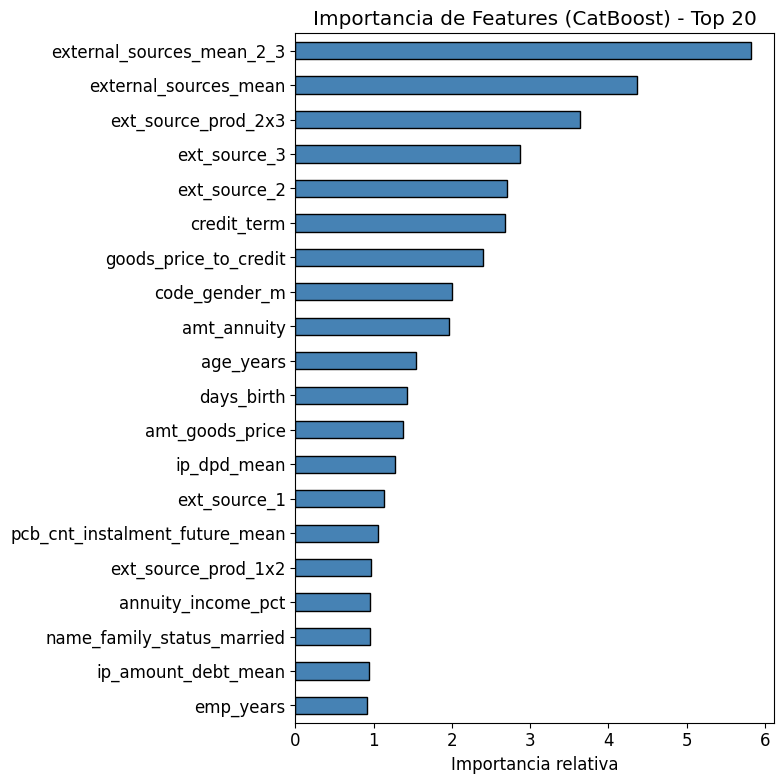

In [5]:
# Calcular y graficar importancias de features
imp = plot_feature_importance(cb, xs, top_k=20, model_name="CatBoost")

In [7]:
gc.collect()

6351

### Con oversampling

In [8]:
# Cargar datos
df_os = pd.read_parquet(os.path.join(PATH, 'prework_train_output_oversampled.parquet'))

for col in df_os.select_dtypes("float64"):
    df_os[col] = df_os[col].astype("float32")
    
# Separar features y target
y = df_os.pop('target')
xs = df_os

# Detectar columnas categóricas automáticamente
cat_features = xs.select_dtypes(include='object').columns.tolist()

# Entrenar y evaluar
cb, auc, proba = fit_transform_cb(xs, y, cat_features=cat_features)
print(f"ROC-AUC (validación): {auc:.6f}")

ROC-AUC (validación): 0.857878


#### Interpretación

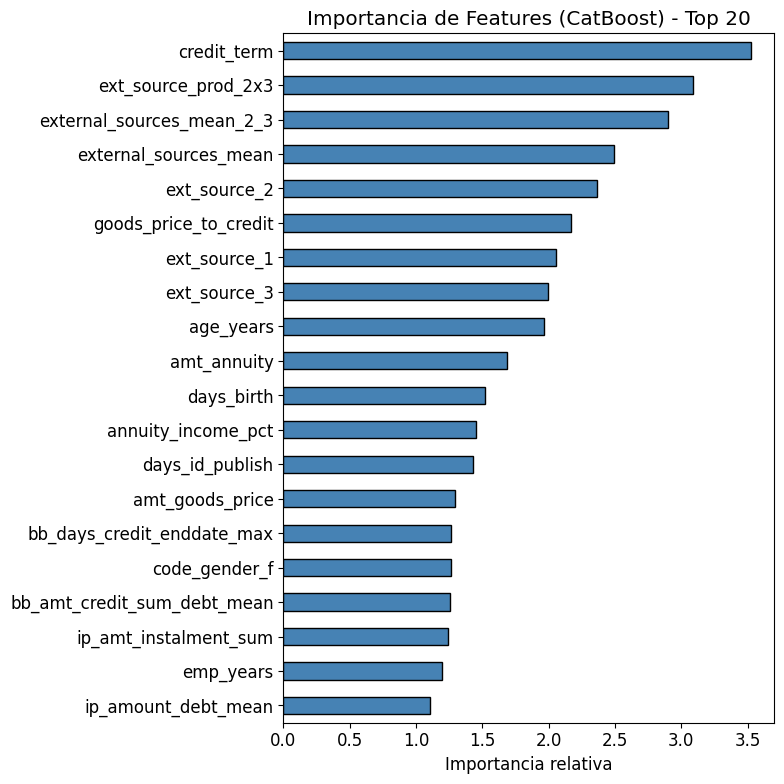

In [9]:
# Calcular y graficar importancias de features
imp = plot_feature_importance(cb, xs, top_k=20, model_name="CatBoost")

In [10]:
# Probamos quedarnos con solo features por arriba del threshold de importancia de features
imp = pd.Series(cb.feature_importances_, index=xs.columns).sort_values(ascending=False) # Importancias

# Filtrar features con importancia > threshold
threshold = 0.3
selected_features = imp[imp > threshold].index
X_reduced = xs[selected_features]

print(f"Total features: {xs.shape[1]}")
print(f"Features retenidas (> {threshold:.2f}): {X_reduced.shape[1]}")
print(f"Features descartadas: {xs.shape[1] - X_reduced.shape[1]}")

Total features: 846
Features retenidas (> 0.30): 86
Features descartadas: 760


In [11]:
# Reentrenar con features reducidas
cb_reduced, auc_reduced, proba_reduced = fit_transform_cb(X_reduced, y)
print(f"ROC-AUC (validación, reduced set): {auc_reduced:.6f}")

ROC-AUC (validación, reduced set): 0.856780


Total features: 846
Features retenidas (> 0.90): 26
Features descartadas: 820


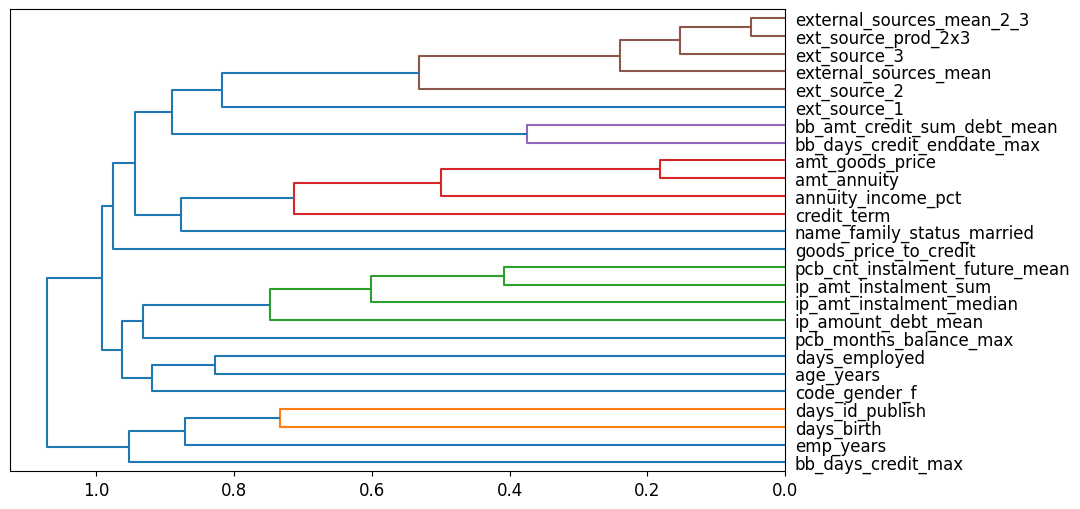

In [16]:
# Estudio de las columnas de a pares para ir viendo cuales "se parecen" en la información que entregan
# haciendo clustering jerarquico de las columnas que las va agrupando según lo parecidas que son, 
# quedandonos con menos features para interpretabilidad
# Filtrar features con importancia > threshold
threshold = 0.9
selected_features = imp[imp > threshold].index
X_reduced = xs[selected_features]

print(f"Total features: {xs.shape[1]}")
print(f"Features retenidas (> {threshold:.2f}): {X_reduced.shape[1]}")
print(f"Features descartadas: {xs.shape[1] - X_reduced.shape[1]}")

cluster_columns(X_reduced)

Top 2 features: ['credit_term', 'ext_source_prod_2x3']


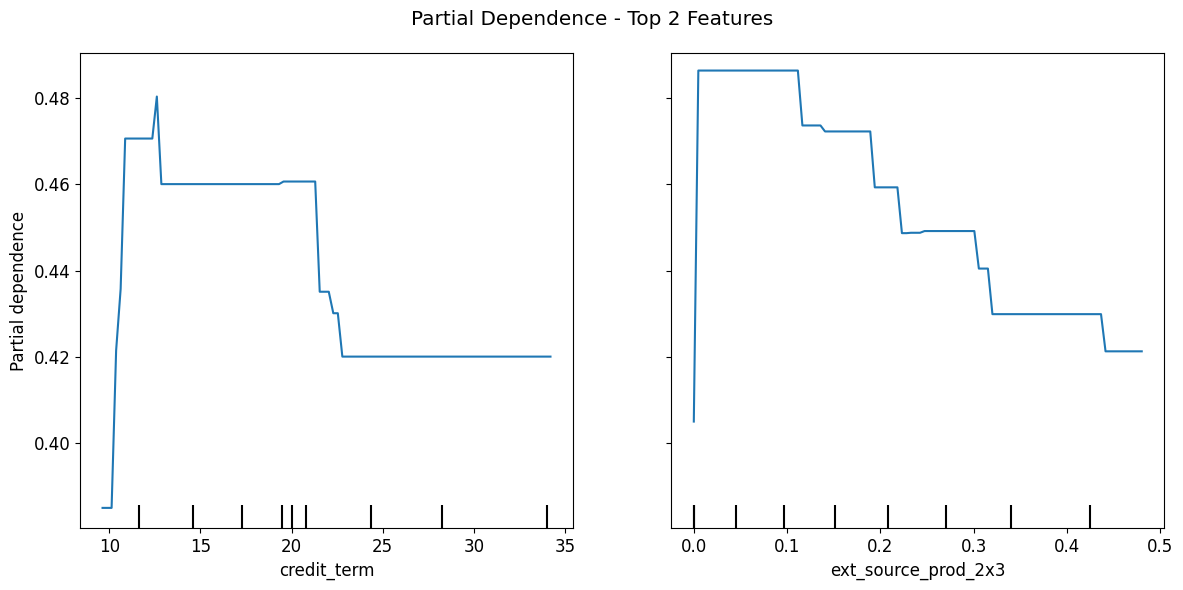

In [17]:
# Partial Dependence: ver cómo las dos variables que resultaron más importantes afectan en la predicción.
top2_features = imp.head(2).index.tolist()
print("Top 2 features:", top2_features)

# Gráfico conjunto de las 2 features más importantes
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    cb, xs, top2_features, ax=ax
)
plt.suptitle("Partial Dependence - Top 2 Features")
plt.tight_layout()
plt.show()

### Model selection

In [ ]:
def random_cv_catboost_reduced(X, y, selected_features, param_distributions,
                               cat_features=None,
                               n_iter=10, sample_size=0.3, n_splits=3, random_state=42):
    """
    Búsqueda aleatoria de hiperparámetros para CatBoost usando SOLO las columnas
    en selected_features. Mantiene la misma lógica y argumentos de la versión original.
    Args:
        X: DataFrame de features completos
        y: Series target
        selected_features: lista/Index de columnas a usar
        param_distributions: dict con listas o tuplas (rangos)
        cat_features: lista de columnas categóricas (nombres). Se intersecta con selected_features.
        n_iter: número de configuraciones aleatorias a probar
        sample_size: fracción (0-1) o entero con tamaño
        n_splits: folds en KFold
        random_state: semilla
    Returns:
        results: lista ordenada por mean_auc desc con dicts {'params','mean_auc','std_auc','fold_scores'}
    """
    np.random.seed(random_state)
    random.seed(random_state)

    # sample size handling
    if 0 < sample_size < 1:
        sample_n = int(len(X) * sample_size)
    elif isinstance(sample_size, int) and sample_size >= 1:
        sample_n = min(sample_size, len(X))
    else:
        raise ValueError("sample_size debe ser fracción (0-1) o entero >=1")

    indices = np.random.choice(len(X), size=sample_n, replace=False)
    X_sample = X.iloc[indices][list(selected_features)].reset_index(drop=True)
    y_sample = y.iloc[indices].reset_index(drop=True)

    # prepare categorical feature names filtered by selected_features
    if cat_features is None:
        cat_feats_in_reduced = None
    else:
        # keep only cat features present in selected_features
        cat_feats_in_reduced = [c for c in cat_features if c in X_sample.columns]
        if len(cat_feats_in_reduced) == 0:
            cat_feats_in_reduced = None

    print(f"Tamaño original del dataset: {len(X)}")
    print(f"Tamaño de la muestra usada en búsqueda: {len(X_sample)}")
    print(f"Usando {len(selected_features)} features seleccionadas")
    if cat_feats_in_reduced:
        print(f"Categorical features usadas: {len(cat_feats_in_reduced)}")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    for i in range(n_iter):
        # sample hyperparameters
        params = {}
        for key, value in param_distributions.items():
            if isinstance(value, list):
                params[key] = random.choice(value)
            elif isinstance(value, tuple) and len(value) == 2:
                params[key] = np.random.uniform(value[0], value[1])
            else:
                params[key] = value

        # cast integer params where appropriate
        if 'iterations' in params:
            params['iterations'] = int(round(params['iterations']))
        if 'depth' in params:
            params['depth'] = int(round(params['depth']))
        if 'min_data_in_leaf' in params:
            params['min_data_in_leaf'] = int(round(params['min_data_in_leaf']))

        fold_scores = []
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_sample), 1):
            X_train, X_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
            y_train, y_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]

            model = CatBoostClassifier(
                **params,
                eval_metric='AUC',
                random_seed=random_state,
                verbose=False
            )

            model.fit(
                X_train, y_train,
                cat_features=cat_feats_in_reduced,
                eval_set=(X_val, y_val),
                early_stopping_rounds=20,
                verbose=False
            )

            y_pred = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_pred)
            fold_scores.append(auc)

        mean_auc = float(np.mean(fold_scores))
        std_auc = float(np.std(fold_scores))

        results.append({
            'params': params,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'fold_scores': fold_scores
        })

        print(f"\nIteración {i+1}/{n_iter}")
        print(f"Parámetros: {params}")
        print(f"AUC medio: {mean_auc:.6f} (±{std_auc:.6f})")
        print("Scores por fold:", fold_scores)
        print("-" * 80)

    results.sort(key=lambda x: x['mean_auc'], reverse=True)
    return results

In [55]:
# param_distributions
param_distributions_cb = {
    'iterations': [100, 200, 300],
    'learning_rate': (0.01, 0.3),
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7],
    'min_data_in_leaf': [10, 20, 30],
    'subsample': (0.7, 1.0),
    'colsample_bylevel': (0.7, 1.0)
}

# Ejecutar búsqueda aleatoria sobre el reduced set
results_cb = random_cv_catboost_reduced(xs, y, selected_features,
                                        param_distributions_cb,
                                        cat_features=cat_features,
                                        n_iter=15, sample_size=0.3, n_splits=3, random_state=42)

# ver top 3
for i, r in enumerate(results_cb[:3], 1):
    print(i, r['mean_auc'], r['params'])

Tamaño original del dataset: 513799
Tamaño de la muestra usada en búsqueda: 154139
Usando 86 features seleccionadas

Iteración 1/15
Parámetros: {'iterations': 300, 'learning_rate': 0.15402662519490565, 'depth': 4, 'l2_leaf_reg': 1, 'min_data_in_leaf': 30, 'subsample': 0.8966859488057706, 'colsample_bylevel': 0.924153386256654}
AUC medio: 0.804438 (±0.001384)
Scores por fold: [0.8026628456937844, 0.8046120836670093, 0.8060385134989474]
--------------------------------------------------------------------------------

Iteración 2/15
Parámetros: {'iterations': 200, 'learning_rate': 0.040469339692488955, 'depth': 6, 'l2_leaf_reg': 3, 'min_data_in_leaf': 10, 'subsample': 0.7715223097457126, 'colsample_bylevel': 0.814182164073592}
AUC medio: 0.781508 (±0.000957)
Scores por fold: [0.7801551429419221, 0.7821724623812569, 0.7821962083930254]
--------------------------------------------------------------------------------

Iteración 3/15
Parámetros: {'iterations': 300, 'learning_rate': 0.25511665

In [56]:
# Entrenar final con los mejores parámetros sobre todo el reduced set
best_params = results_cb[0]['params']
cb_final = CatBoostClassifier(**best_params, random_seed=42, verbose=False)
cb_final.fit(xs[selected_features], y, cat_features=[c for c in (cat_features or []) if c in selected_features])

#### Predict & submission

In [57]:
# Preparar df_test de la misma forma que hiciste para RF (alinear, imputar, dtypes)
df_test = pd.read_parquet(os.path.join(PATH, "prework_test_output.parquet"))
for col in df_test.select_dtypes("float64"):
    df_test[col] = df_test[col].astype("float32")

ids = df_test["sk_id_curr"].copy()

# Alinear columnas reducidas
reduced_cols = list(selected_features)
for c in reduced_cols:
    if c not in df_test.columns:
        df_test[c] = 0.0
extra_cols = [c for c in df_test.columns if c not in reduced_cols and c != "sk_id_curr"]
if extra_cols:
    df_test = df_test.drop(columns=extra_cols)
df_test_reduced = df_test[reduced_cols].copy()

if df_test_reduced.isna().sum().sum() != 0:
    raise ValueError("Hay NaNs en df_test_reduced; imputar con la misma estrategia que en train")
for col in df_test_reduced.select_dtypes("float64"):
    df_test_reduced[col] = df_test_reduced[col].astype("float32")

# Predecir y guardar submission
proba_test = cb_final.predict_proba(df_test_reduced)[:, 1]
FILENAME = "predictions_test_reduced_final_cb.csv"
out = pd.DataFrame({"SK_ID_CURR": ids.values, "TARGET": proba_test})
out.to_csv(os.path.join(PATH, FILENAME), index=False)
print("Predicciones guardadas en:", os.path.join(PATH, FILENAME))

Predicciones guardadas en: C:/Users/julia/ML_TP\predictions_test_reduced_final_cb.csv
